# Agricultural Pest Detection — DLP Week 10

**Goal**: Detect and classify 23 agricultural pest species → maximize mAP@IoU=0.5  
**Model**: YOLOv8x (pretrained COCO → fine-tuned on pest data)  
**Dataset**: 12,701 training images · 2,580 test images · 800×600 px · 102,472 annotations

## 0. Install & Imports

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.3 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import shutil
import random
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
import yaml
import torch
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 72          # lower DPI → smaller embedded PNGs → no browser OOM
plt.rcParams['figure.figsize'] = (12, 4) # smaller default size

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


## 1. Configuration

In [3]:
KAGGLE_INPUT = Path('/kaggle/input')
WORK_DIR     = Path('/kaggle/working')

# Search recursively for the folder containing train.csv
BASE_DIR = None
for p in sorted(KAGGLE_INPUT.rglob('train.csv')):
    BASE_DIR = p.parent
    break

if BASE_DIR is None:
    raise FileNotFoundError(
        f"train.csv not found anywhere under {KAGGLE_INPUT}.\n"
        f"Contents: {list(KAGGLE_INPUT.rglob('*'))[:30]}"
    )

print(f"Dataset root : {BASE_DIR}")

TRAIN_CSV  = BASE_DIR / 'train.csv'
SAMPLE_SUB = BASE_DIR / 'sample_submission.csv'
TEST_DIR   = BASE_DIR / 'test'

_train_subdir = BASE_DIR / 'train'
TRAIN_IMG_DIR = _train_subdir if _train_subdir.is_dir() else BASE_DIR
print(f"Train images : {TRAIN_IMG_DIR}")
print(f"Test  images : {TEST_DIR}")

DATASET_DIR = WORK_DIR / 'dataset'

# ── Model & Training ──────────────────────────────────────────────────────────
# yolov8m @ 640px, batch=16 → ~3.5 GPU hours for 40 epochs
# Leaves 26+ hrs of weekly budget for a second run after reviewing leaderboard score
MODEL_NAME = 'yolov8m.pt'
IMG_SIZE   = 640
EPOCHS     = 40
BATCH_SIZE = 16
VAL_SPLIT  = 0.1
SEED       = 42

# ── Inference ─────────────────────────────────────────────────────────────────
CONF_THRESH = 0.25
NMS_IOU     = 0.5
INFER_BATCH = 32   # larger batch is fine at inference time

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

assert TRAIN_CSV.exists(),     f"train.csv not found at {TRAIN_CSV}"
assert TEST_DIR.exists(),      f"test/ folder not found at {TEST_DIR}"
assert SAMPLE_SUB.exists(),    f"sample_submission.csv not found at {SAMPLE_SUB}"
assert TRAIN_IMG_DIR.exists(), f"Training images folder not found at {TRAIN_IMG_DIR}"
print("All paths validated.")

Dataset root : /kaggle/input/competitions/object-detetction-week-10-dlp
Train images : /kaggle/input/competitions/object-detetction-week-10-dlp/train
Test  images : /kaggle/input/competitions/object-detetction-week-10-dlp/test
All paths validated.


## 2. Exploratory Data Analysis

Understanding the data **before** training lets us make informed hyperparameter decisions rather than guessing.

In [4]:
df = pd.read_csv(TRAIN_CSV)

# Derived columns
df['bbox_w']      = df['x_max'] - df['x_min']
df['bbox_h']      = df['y_max'] - df['y_min']
df['bbox_area']   = df['bbox_w'] * df['bbox_h']
df['rel_w']       = df['bbox_w'] / df['width']   # fraction of image width
df['rel_h']       = df['bbox_h'] / df['height']
df['aspect_ratio']= df['bbox_w'] / df['bbox_h']

print("=" * 55)
print(f"  Total annotations : {len(df):,}")
print(f"  Training images   : {df['image_id'].nunique():,}")
print(f"  Test images       : {len(list(TEST_DIR.glob('*.jpg'))):,}")
print(f"  Number of classes : {df['class_name'].nunique()}")
print(f"  Image resolution  : {df['width'].iloc[0]}×{df['height'].iloc[0]}")
print("=" * 55)
print()
print("Missing values:")
print(df.isnull().sum())

  Total annotations : 102,472
  Training images   : 12,701
  Test images       : 7,600
  Number of classes : 23
  Image resolution  : 800×600

Missing values:
image_id        0
class_name      0
x_min           0
y_min           0
x_max           0
y_max           0
width           0
height          0
bbox_w          0
bbox_h          0
bbox_area       0
rel_w           0
rel_h           0
aspect_ratio    0
dtype: int64


### 2.1 Class Distribution  
**Finding**: Extreme imbalance — RiceWaterWeevil (29,735) vs WhiteMarginedMoth (54), a 550× ratio.

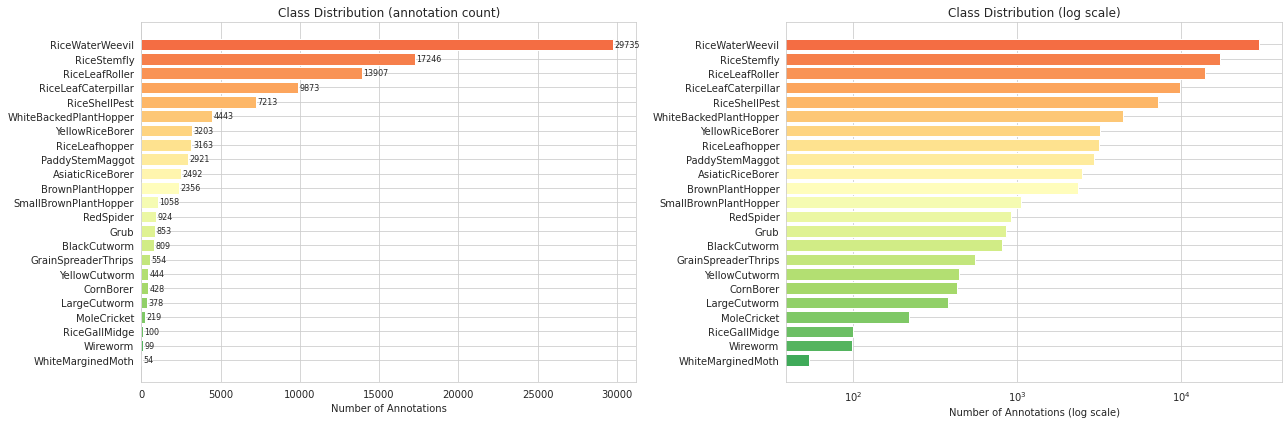


Imbalance ratio (max/min): 551×

Classes with < 500 samples (rare):
class_name
YellowCutworm        444
CornBorer            428
LargeCutworm         378
MoleCricket          219
RiceGallMidge        100
Wireworm              99
WhiteMarginedMoth     54
Name: count, dtype: int64


In [5]:
class_counts = df['class_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(class_counts)))[::-1]
axes[0].barh(class_counts.index[::-1], class_counts.values[::-1], color=colors)
axes[0].set_xlabel('Number of Annotations')
axes[0].set_title('Class Distribution (annotation count)')
for i, (v, name) in enumerate(zip(class_counts.values[::-1], class_counts.index[::-1])):
    axes[0].text(v + 100, i, str(v), va='center', fontsize=8)

# Log-scale to see tail
axes[1].barh(class_counts.index[::-1], class_counts.values[::-1], color=colors)
axes[1].set_xscale('log')
axes[1].set_xlabel('Number of Annotations (log scale)')
axes[1].set_title('Class Distribution (log scale)')

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (max/min): {class_counts.max() / class_counts.min():.0f}×")
print(f"\nClasses with < 500 samples (rare):")
print(class_counts[class_counts < 500])

### 2.2 Bounding Box Size Distribution  
**Finding**: Objects are small — mean ~34×34 px on 800×600 images (~4% of image width). This drives using `imgsz=800` instead of 640.

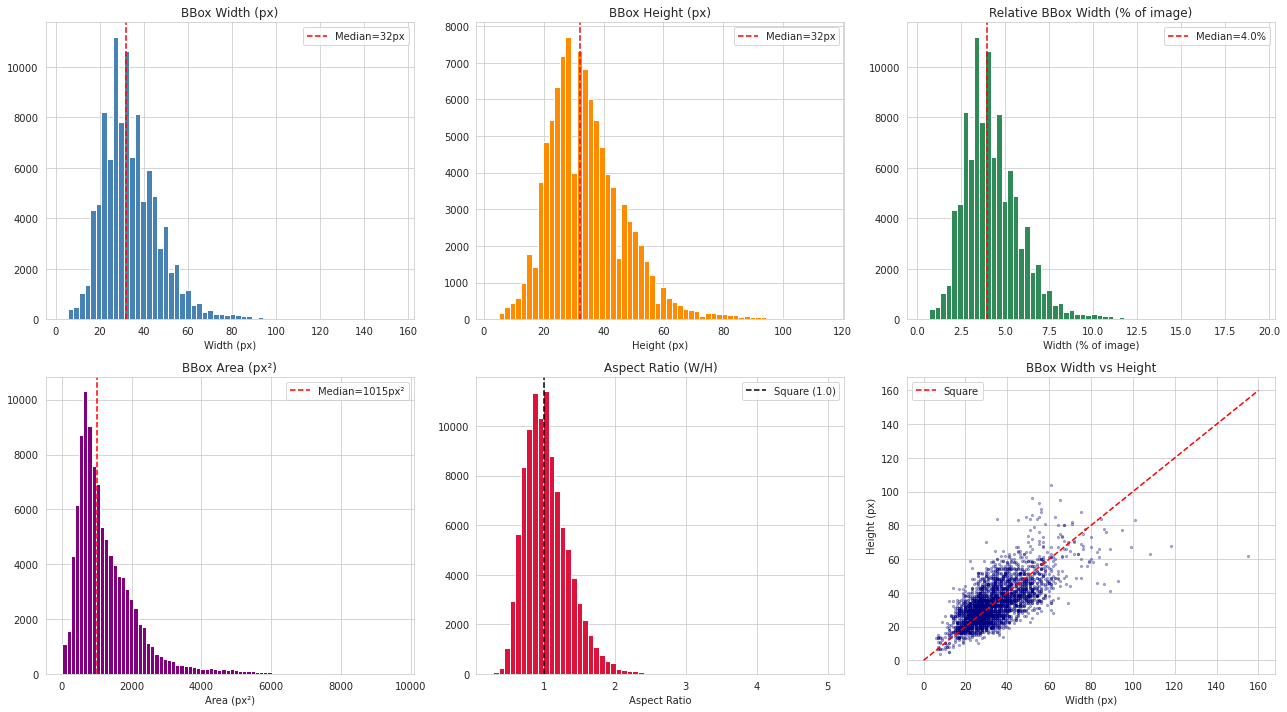

BBox size summary:
          bbox_w     bbox_h  bbox_area      rel_w
count  102472.00  102472.00  102472.00  102472.00
mean       34.09      34.25    1282.88       0.04
std        12.99      12.96     957.84       0.02
min         3.00       3.00      12.00       0.00
25%        25.00      25.00     651.00       0.03
50%        32.00      32.00    1015.00       0.04
75%        41.00      41.00    1656.00       0.05
max       155.00     115.00    9610.00       0.19


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Absolute width
axes[0, 0].hist(df['bbox_w'], bins=60, color='steelblue', edgecolor='white')
axes[0, 0].axvline(df['bbox_w'].median(), color='red', linestyle='--', label=f"Median={df['bbox_w'].median():.0f}px")
axes[0, 0].set_title('BBox Width (px)')
axes[0, 0].set_xlabel('Width (px)')
axes[0, 0].legend()

# Absolute height
axes[0, 1].hist(df['bbox_h'], bins=60, color='darkorange', edgecolor='white')
axes[0, 1].axvline(df['bbox_h'].median(), color='red', linestyle='--', label=f"Median={df['bbox_h'].median():.0f}px")
axes[0, 1].set_title('BBox Height (px)')
axes[0, 1].set_xlabel('Height (px)')
axes[0, 1].legend()

# Relative size (% of image)
axes[0, 2].hist(df['rel_w'] * 100, bins=60, color='seagreen', edgecolor='white')
axes[0, 2].axvline(df['rel_w'].median() * 100, color='red', linestyle='--',
                   label=f"Median={df['rel_w'].median()*100:.1f}%")
axes[0, 2].set_title('Relative BBox Width (% of image)')
axes[0, 2].set_xlabel('Width (% of image)')
axes[0, 2].legend()

# Area distribution
axes[1, 0].hist(df['bbox_area'], bins=80, color='purple', edgecolor='white')
axes[1, 0].axvline(df['bbox_area'].median(), color='red', linestyle='--',
                   label=f"Median={df['bbox_area'].median():.0f}px²")
axes[1, 0].set_title('BBox Area (px²)')
axes[1, 0].set_xlabel('Area (px²)')
axes[1, 0].legend()

# Aspect ratio
axes[1, 1].hist(df['aspect_ratio'], bins=60, color='crimson', edgecolor='white')
axes[1, 1].axvline(1.0, color='black', linestyle='--', label='Square (1.0)')
axes[1, 1].set_title('Aspect Ratio (W/H)')
axes[1, 1].set_xlabel('Aspect Ratio')
axes[1, 1].legend()

# W vs H scatter
sample = df.sample(min(3000, len(df)), random_state=42)
axes[1, 2].scatter(sample['bbox_w'], sample['bbox_h'], alpha=0.3, s=5, color='navy')
axes[1, 2].plot([0, 160], [0, 160], 'r--', label='Square')
axes[1, 2].set_title('BBox Width vs Height')
axes[1, 2].set_xlabel('Width (px)')
axes[1, 2].set_ylabel('Height (px)')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("BBox size summary:")
print(df[['bbox_w', 'bbox_h', 'bbox_area', 'rel_w']].describe().round(2))

### 2.3 Object Size by Class  
**Finding**: Some classes (e.g. Wireworm, GrainSpreaderThrips) have significantly smaller bounding boxes than others.

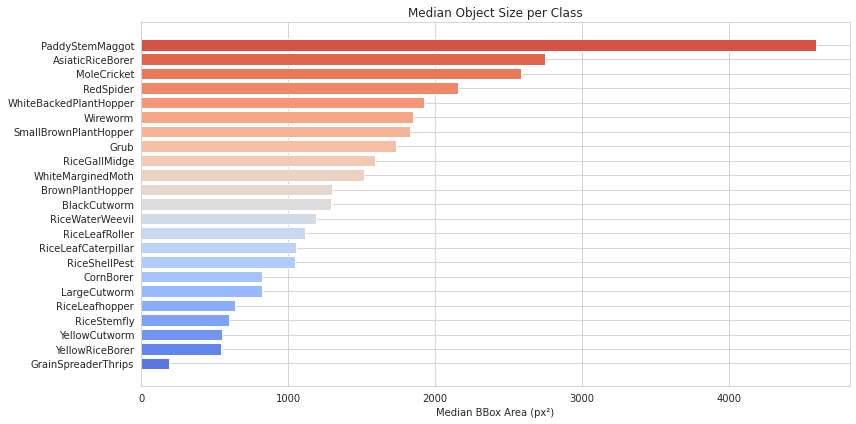

In [7]:
class_size = df.groupby('class_name')['bbox_area'].median().sort_values()

plt.figure(figsize=(12, 6))
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(class_size)))
plt.barh(class_size.index, class_size.values, color=colors)
plt.xlabel('Median BBox Area (px²)')
plt.title('Median Object Size per Class')
plt.tight_layout()
plt.show()

### 2.4 Objects Per Image  
**Finding**: Median 3 objects/image, max 202 — high-density images are real. Mosaic augmentation helps with these.

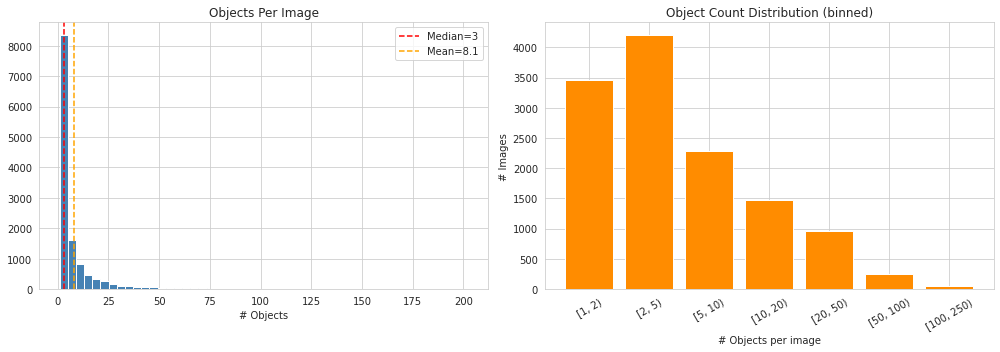

Images with 1 object  : 3,464
Images with >10 objects: 2,502
Images with >50 objects: 300


In [8]:
objs_per_img = df.groupby('image_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(objs_per_img, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(objs_per_img.median(), color='red', linestyle='--',
                label=f'Median={objs_per_img.median():.0f}')
axes[0].axvline(objs_per_img.mean(), color='orange', linestyle='--',
                label=f'Mean={objs_per_img.mean():.1f}')
axes[0].set_title('Objects Per Image')
axes[0].set_xlabel('# Objects')
axes[0].legend()

# Images with 1 object vs many
bins = [1, 2, 5, 10, 20, 50, 100, 250]
counts = pd.cut(objs_per_img, bins=bins, right=False).value_counts().sort_index()
axes[1].bar(range(len(counts)), counts.values, color='darkorange', edgecolor='white')
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels([str(b) for b in counts.index], rotation=30)
axes[1].set_title('Object Count Distribution (binned)')
axes[1].set_xlabel('# Objects per image')
axes[1].set_ylabel('# Images')

plt.tight_layout()
plt.show()

print(f"Images with 1 object  : {(objs_per_img == 1).sum():,}")
print(f"Images with >10 objects: {(objs_per_img > 10).sum():,}")
print(f"Images with >50 objects: {(objs_per_img > 50).sum():,}")

### 2.5 Bounding Box Position Heatmap  
**Finding**: Object positions are fairly uniform across the image — no strong spatial bias.

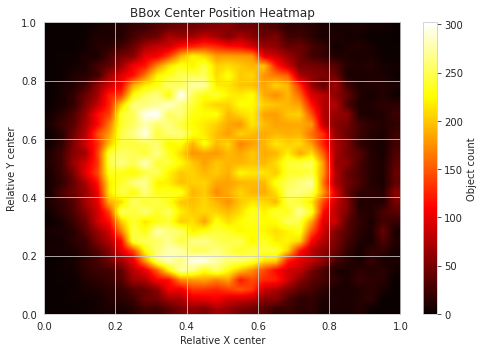

In [9]:
cx = ((df['x_min'] + df['x_max']) / 2) / df['width']
cy = ((df['y_min'] + df['y_max']) / 2) / df['height']

heatmap, xedges, yedges = np.histogram2d(cx, cy, bins=30)

plt.figure(figsize=(7, 5))
plt.imshow(heatmap.T, origin='lower', extent=[0, 1, 0, 1],
           aspect='auto', cmap='hot', interpolation='bilinear')
plt.colorbar(label='Object count')
plt.xlabel('Relative X center')
plt.ylabel('Relative Y center')
plt.title('BBox Center Position Heatmap')
plt.tight_layout()
plt.show()

### 2.6 Sample Images with Annotations

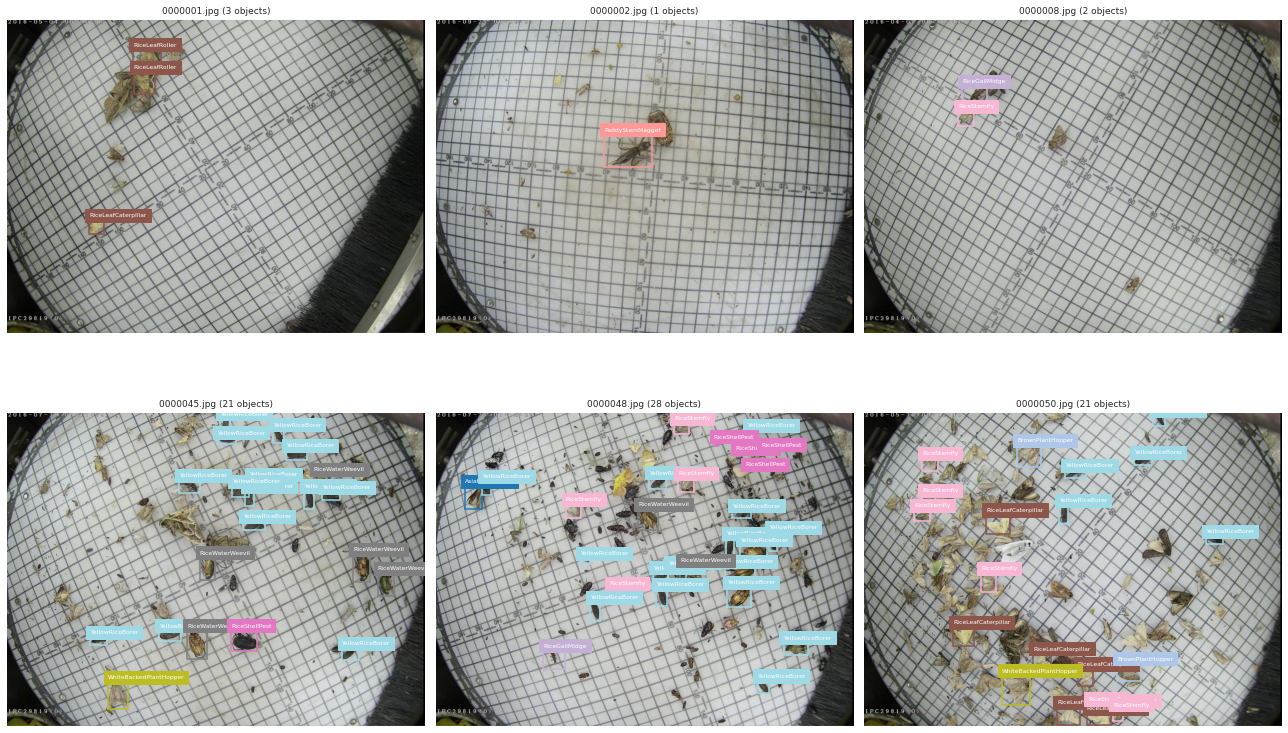

In [10]:
def show_annotated_images(image_ids, df, img_dir, ncols=3, figsize=(18, 12)):
    nrows = (len(image_ids) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()
    cmap = plt.cm.get_cmap('tab20', df['class_name'].nunique())
    classes_list = sorted(df['class_name'].unique())
    cls_color = {c: cmap(i) for i, c in enumerate(classes_list)}

    for ax, img_id in zip(axes, image_ids):
        img_path = img_dir / img_id
        if not img_path.exists():
            ax.axis('off')
            continue
        img = Image.open(img_path)
        ax.imshow(img)
        rows = df[df['image_id'] == img_id]
        for _, row in rows.iterrows():
            x, y = row['x_min'], row['y_min']
            w, h = row['x_max'] - row['x_min'], row['y_max'] - row['y_min']
            color = cls_color[row['class_name']]
            rect = patches.Rectangle((x, y), w, h, linewidth=1.5,
                                      edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y - 2, row['class_name'], fontsize=6,
                    color='white', backgroundcolor=color, clip_on=True)
        ax.set_title(f"{img_id} ({len(rows)} objects)", fontsize=9)
        ax.axis('off')

    for ax in axes[len(image_ids):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# Show 6 images: mix of low/high density
low_density  = objs_per_img[objs_per_img <= 3].index[:3].tolist()
high_density = objs_per_img[objs_per_img >= 20].index[:3].tolist()
sample_ids   = low_density + high_density

show_annotated_images(sample_ids, df, TRAIN_IMG_DIR)

### 2.7 EDA Summary → Hyperparameter Decisions

| Finding | Impact | Decision |
|---------|--------|----------|
| Objects avg 34×34px on 800px image | Small objects need high resolution | `imgsz=800` |
| 550× class imbalance | Rare classes under-detected | Focal loss (built-in YOLO), oversample via mosaic |
| Max 202 objects/image | Dense scenes need good NMS | Keep `iou=0.5` for NMS |
| All images 800×600, uniform bg | No strong spatial bias | Standard augmentation |
| Objects roughly square (AR≈1) | No special anchor tuning needed | Default anchors OK |

## 3. Prepare YOLO Dataset

In [11]:
# Build class mapping (sorted alphabetically → stable across runs)
classes   = sorted(df['class_name'].unique().tolist())  # Python list, not numpy
class2idx = {c: i for i, c in enumerate(classes)}
idx2class = {i: c for c, i in class2idx.items()}

print(f"Number of classes: {len(classes)}")
for i, c in idx2class.items():
    print(f"  {i:2d}: {c}")

Number of classes: 23
   0: AsiaticRiceBorer
   1: BlackCutworm
   2: BrownPlantHopper
   3: CornBorer
   4: GrainSpreaderThrips
   5: Grub
   6: LargeCutworm
   7: MoleCricket
   8: PaddyStemMaggot
   9: RedSpider
  10: RiceGallMidge
  11: RiceLeafCaterpillar
  12: RiceLeafRoller
  13: RiceLeafhopper
  14: RiceShellPest
  15: RiceStemfly
  16: RiceWaterWeevil
  17: SmallBrownPlantHopper
  18: WhiteBackedPlantHopper
  19: WhiteMarginedMoth
  20: Wireworm
  21: YellowCutworm
  22: YellowRiceBorer


In [12]:
# Create YOLO directory structure
for split in ['train', 'val']:
    (DATASET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

# Stratified-by-image train/val split (ensures rare classes appear in both)
all_image_ids = df['image_id'].unique().tolist()   # Python list
random.shuffle(all_image_ids)                      # seed set at top
n_val        = int(len(all_image_ids) * VAL_SPLIT)
val_ids      = set(all_image_ids[:n_val])
train_ids    = set(all_image_ids[n_val:])

print(f"Train images : {len(train_ids):,}")
print(f"Val   images : {len(val_ids):,}")

Train images : 11,431
Val   images : 1,270


In [13]:
def bbox_to_yolo(x_min, y_min, x_max, y_max, img_w, img_h):
    """Absolute xyxy → YOLO normalized cx cy w h, clamped to [0,1]."""
    cx = (x_min + x_max) / 2.0 / img_w
    cy = (y_min + y_max) / 2.0 / img_h
    w  = (x_max - x_min) / img_w
    h  = (y_max - y_min) / img_h
    cx = max(0.0, min(1.0, cx))
    cy = max(0.0, min(1.0, cy))
    w  = max(1e-4, min(1.0, w))
    h  = max(1e-4, min(1.0, h))
    return cx, cy, w, h


def write_yolo_files(image_id, split):
    """Copy image + write YOLO label file. Returns True on success."""
    src = TRAIN_IMG_DIR / image_id
    if not src.exists():
        return False

    shutil.copy2(src, DATASET_DIR / split / 'images' / image_id)

    rows  = df[df['image_id'] == image_id]
    img_w = int(rows.iloc[0]['width'])
    img_h = int(rows.iloc[0]['height'])
    lbl   = DATASET_DIR / split / 'labels' / (Path(image_id).stem + '.txt')

    with open(lbl, 'w') as f:
        for _, row in rows.iterrows():
            cls_id = class2idx[row['class_name']]
            cx, cy, w, h = bbox_to_yolo(
                row['x_min'], row['y_min'], row['x_max'], row['y_max'],
                img_w, img_h
            )
            f.write(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
    return True

In [14]:
missing = 0
for img_id in tqdm(train_ids, desc='Prepare train'):
    if not write_yolo_files(img_id, 'train'):
        missing += 1

for img_id in tqdm(val_ids, desc='Prepare val'):
    if not write_yolo_files(img_id, 'val'):
        missing += 1

n_train_imgs = len(list((DATASET_DIR / 'train' / 'images').glob('*.jpg')))
n_val_imgs   = len(list((DATASET_DIR / 'val'   / 'images').glob('*.jpg')))
n_train_lbls = len(list((DATASET_DIR / 'train' / 'labels').glob('*.txt')))
n_val_lbls   = len(list((DATASET_DIR / 'val'   / 'labels').glob('*.txt')))

print(f"Train  — images: {n_train_imgs:,}  labels: {n_train_lbls:,}")
print(f"Val    — images: {n_val_imgs:,}  labels: {n_val_lbls:,}")
print(f"Missing images : {missing}")
assert n_train_imgs == n_train_lbls, "Image/label count mismatch in train!"
assert n_val_imgs   == n_val_lbls,   "Image/label count mismatch in val!"
print("Dataset structure validated.")

Prepare train:   0%|          | 0/11431 [00:00<?, ?it/s]

Prepare val:   0%|          | 0/1270 [00:00<?, ?it/s]

Train  — images: 11,431  labels: 11,431
Val    — images: 1,270  labels: 1,270
Missing images : 0
Dataset structure validated.


In [15]:
# Write dataset YAML
yaml_cfg = {
    'path'  : str(DATASET_DIR),
    'train' : 'train/images',
    'val'   : 'val/images',
    'nc'    : len(classes),
    'names' : classes          # Python list — YOLO needs this exactly
}

yaml_path = WORK_DIR / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_cfg, f, default_flow_style=None, sort_keys=False)

print(f"YAML written to: {yaml_path}")
print(open(yaml_path).read())

YAML written to: /kaggle/working/dataset.yaml
path: /kaggle/working/dataset
train: train/images
val: val/images
nc: 23
names: [AsiaticRiceBorer, BlackCutworm, BrownPlantHopper, CornBorer, GrainSpreaderThrips,
  Grub, LargeCutworm, MoleCricket, PaddyStemMaggot, RedSpider, RiceGallMidge, RiceLeafCaterpillar,
  RiceLeafRoller, RiceLeafhopper, RiceShellPest, RiceStemfly, RiceWaterWeevil, SmallBrownPlantHopper,
  WhiteBackedPlantHopper, WhiteMarginedMoth, Wireworm, YellowCutworm, YellowRiceBorer]



## 4. Train YOLOv8m

In [ ]:
from ultralytics import YOLO

model = YOLO(MODEL_NAME)   # COCO pretrained weights

train_results = model.train(
    data          = str(yaml_path),
    epochs        = EPOCHS,
    imgsz         = IMG_SIZE,
    batch         = BATCH_SIZE,
    device        = 0 if torch.cuda.is_available() else 'cpu',
    project       = str(WORK_DIR / 'runs'),
    name          = 'pest_v1',
    exist_ok      = True,
    # Stopping
    patience      = 10,
    # Optimizer
    optimizer     = 'AdamW',
    lr0           = 0.001,
    lrf           = 0.01,
    momentum      = 0.937,
    weight_decay  = 0.0005,
    warmup_epochs = 3,
    # Augmentation
    hsv_h         = 0.015,
    hsv_s         = 0.7,
    hsv_v         = 0.4,
    degrees       = 5.0,
    translate     = 0.1,
    scale         = 0.5,
    fliplr        = 0.5,
    flipud        = 0.0,
    mosaic        = 1.0,
    mixup         = 0.1,
    copy_paste    = 0.0,
    # Memory / IO — disk cache needs 23GB but Kaggle only has ~19GB free
    cache         = False,
    workers       = 4,
    # verbose=False prevents browser tab OOM from training log flooding
    verbose       = False,
    save          = True,
    save_period   = 5,
    val           = True,
    seed          = SEED,
)

print(f"Best mAP50 : {train_results.results_dict.get('metrics/mAP50(B)', 'N/A')}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=

In [ ]:
# Locate the best checkpoint
best_ckpt = WORK_DIR / 'runs' / 'pest_v1' / 'weights' / 'best.pt'
last_ckpt = WORK_DIR / 'runs' / 'pest_v1' / 'weights' / 'last.pt'

assert best_ckpt.exists(), f"best.pt not found — training may have failed: {best_ckpt}"
print(f"best.pt : {best_ckpt}")
print(f"last.pt : {last_ckpt}")

## 5. Validation Metrics

In [ ]:
best_model = YOLO(str(best_ckpt))

val_metrics = best_model.val(
    data    = str(yaml_path),
    imgsz   = IMG_SIZE,
    conf    = CONF_THRESH,
    iou     = 0.5,
    device  = 0 if torch.cuda.is_available() else 'cpu',
    verbose = False,
)

print(f"\n{'='*40}")
print(f"  mAP@0.5      : {val_metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {val_metrics.box.map:.4f}")
print(f"  Precision    : {val_metrics.box.mp:.4f}")
print(f"  Recall       : {val_metrics.box.mr:.4f}")
print(f"{'='*40}")

In [ ]:
# Per-class mAP
if hasattr(val_metrics.box, 'ap_class_index'):
    per_class_ap = val_metrics.box.ap50
    class_names_val = [classes[i] for i in val_metrics.box.ap_class_index]
    per_class_df = pd.DataFrame({'class': class_names_val, 'AP50': per_class_ap})
    per_class_df = per_class_df.sort_values('AP50')

    plt.figure(figsize=(10, 6))
    colors = plt.cm.RdYlGn(per_class_df['AP50'])
    plt.barh(per_class_df['class'], per_class_df['AP50'], color=colors)
    plt.axvline(per_class_df['AP50'].mean(), color='red', linestyle='--',
                label=f"Mean={per_class_df['AP50'].mean():.3f}")
    plt.xlabel('AP@0.5')
    plt.title('Per-Class Average Precision @ IoU 0.5')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nWorst performing classes:")
    print(per_class_df.head(5).to_string(index=False))

## 6. Confidence Threshold Tuning

In [ ]:
# Sweep confidence thresholds on validation set to find the best one
conf_results = []
for conf in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
    r = best_model.val(
        data=str(yaml_path), imgsz=IMG_SIZE, conf=conf, iou=0.5,
        device=0 if torch.cuda.is_available() else 'cpu', verbose=False
    )
    conf_results.append({'conf': conf, 'mAP50': r.box.map50})
    print(f"  conf={conf:.2f}  mAP50={r.box.map50:.4f}")

conf_df = pd.DataFrame(conf_results)
best_conf_row = conf_df.loc[conf_df['mAP50'].idxmax()]
BEST_CONF = float(best_conf_row['conf'])
print(f"\nBest confidence threshold: {BEST_CONF}  (mAP50={best_conf_row['mAP50']:.4f})") 

plt.figure(figsize=(8, 4))
plt.plot(conf_df['conf'], conf_df['mAP50'], marker='o')
plt.axvline(BEST_CONF, color='red', linestyle='--', label=f'Best={BEST_CONF}')
plt.xlabel('Confidence Threshold')
plt.ylabel('mAP@0.5')
plt.title('mAP vs Confidence Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Generate Predictions on Test Set

In [ ]:
test_image_paths = sorted(TEST_DIR.glob('*.jpg'))
print(f"Test images: {len(test_image_paths)}")

In [ ]:
def format_prediction_string(result):
    """Convert a single YOLO result → competition PredictionString.

    Format: Label Confidence X_min Y_min X_max Y_max (space-separated per object)
    Coordinates are absolute integer pixel values.
    """
    if result.boxes is None or len(result.boxes) == 0:
        return ''

    parts = []
    # Vectorised extraction (faster than looping one box at a time)
    xyxy   = result.boxes.xyxy.cpu().numpy()   # (N, 4)
    confs  = result.boxes.conf.cpu().numpy()   # (N,)
    clsids = result.boxes.cls.cpu().numpy().astype(int)  # (N,)

    for cls_id, conf, (x1, y1, x2, y2) in zip(clsids, confs, xyxy):
        label = idx2class[cls_id]
        parts.append(f"{label} {conf:.4f} {int(x1)} {int(y1)} {int(x2)} {int(y2)}")

    return ' '.join(parts)

In [ ]:
predictions = {}

for i in tqdm(range(0, len(test_image_paths), INFER_BATCH), desc='Inference'):
    batch_paths = test_image_paths[i : i + INFER_BATCH]
    results = best_model.predict(
        source  = [str(p) for p in batch_paths],
        imgsz   = IMG_SIZE,
        conf    = BEST_CONF,
        iou     = NMS_IOU,
        device  = 0 if torch.cuda.is_available() else 'cpu',
        augment = True,      # test-time augmentation boosts mAP
        verbose = False,
    )
    for path, res in zip(batch_paths, results):
        predictions[path.name] = format_prediction_string(res)

n_empty = sum(1 for v in predictions.values() if v == '')
print(f"Predicted {len(predictions)} images — {n_empty} with no detections")

## 8. Build & Save Submission CSV

In [ ]:
sample_sub = pd.read_csv(SAMPLE_SUB)
print(f"Sample submission shape: {sample_sub.shape}")
sample_sub.head(3)

In [ ]:
pred_df = pd.DataFrame([
    {'ImageID': img_id, 'PredictionString': pred_str}
    for img_id, pred_str in predictions.items()
])

# Left-join on sample_submission to guarantee row order and coverage
submission = sample_sub[['ImageID']].merge(pred_df, on='ImageID', how='left')
submission['PredictionString'] = submission['PredictionString'].fillna('')

# Sanity checks
assert len(submission) == len(sample_sub), \
    f"Row count mismatch: {len(submission)} vs {len(sample_sub)}"
assert list(submission.columns) == ['ImageID', 'PredictionString'], \
    f"Wrong columns: {list(submission.columns)}"

print(f"Submission rows          : {len(submission):,}")
print(f"Images with detections   : {(submission['PredictionString'] != '').sum():,}")
print(f"Images with no detections: {(submission['PredictionString'] == '').sum():,}")
print()
submission.head(5)

In [ ]:
# Validate PredictionString format on a sample
sample_preds = submission[submission['PredictionString'] != ''].head(3)
for _, row in sample_preds.iterrows():
    tokens = row['PredictionString'].split()
    n_objs = len(tokens) // 6
    print(f"{row['ImageID']}  ({n_objs} objects detected)")
    for j in range(n_objs):
        t = tokens[j*6 : j*6+6]
        print(f"    label={t[0]}  conf={t[1]}  bbox=[{t[2]},{t[3]},{t[4]},{t[5]}]")

In [ ]:
# Save CSV
sub_path = WORK_DIR / 'submission.csv'
submission.to_csv(sub_path, index=False)
print(f"Submission CSV saved → {sub_path}")
print(f"File size: {sub_path.stat().st_size / 1024:.1f} KB")

# Final read-back check
check = pd.read_csv(sub_path)
assert list(check.columns) == ['ImageID', 'PredictionString']
assert len(check) == len(sample_sub)
print("Read-back validation passed.")

## 9. Visualise Predictions on Test Samples

In [ ]:
def show_test_predictions(image_ids, submission_df, test_dir, ncols=3, figsize=(18, 12)):
    """Visualise predicted bounding boxes on test images."""
    nrows = (len(image_ids) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()
    cmap = plt.cm.get_cmap('tab20', len(classes))
    cls_color = {c: cmap(i) for i, c in enumerate(classes)}

    for ax, img_id in zip(axes, image_ids):
        img_path = test_dir / img_id
        if not img_path.exists():
            ax.axis('off')
            continue
        img = Image.open(img_path)
        ax.imshow(img)

        pred_str = submission_df.loc[submission_df['ImageID'] == img_id, 'PredictionString'].values
        if len(pred_str) > 0 and pred_str[0] != '':
            tokens = pred_str[0].split()
            n_objs = len(tokens) // 6
            for j in range(n_objs):
                t     = tokens[j*6 : j*6+6]
                label = t[0]
                conf  = float(t[1])
                x1, y1, x2, y2 = int(t[2]), int(t[3]), int(t[4]), int(t[5])
                color = cls_color.get(label, (1, 0, 0, 1))
                rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          linewidth=1.5, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1-2, f"{label} {conf:.2f}", fontsize=6,
                        color='white', backgroundcolor=color, clip_on=True)
            ax.set_title(f"{img_id} ({n_objs} dets)", fontsize=9)
        else:
            ax.set_title(f"{img_id} (no dets)", fontsize=9, color='red')
        ax.axis('off')

    for ax in axes[len(image_ids):]:
        ax.axis('off')
    plt.suptitle('Test Set Predictions', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# Show 6 random test images
sample_test_ids = [p.name for p in random.sample(test_image_paths, min(6, len(test_image_paths)))]
show_test_predictions(sample_test_ids, submission, TEST_DIR)

## 10. Prediction Statistics

In [ ]:
# Count predicted objects per test image and per class
pred_class_counts = Counter()
objs_per_test_img = []

for _, row in submission.iterrows():
    s = row['PredictionString']
    if s == '':
        objs_per_test_img.append(0)
        continue
    tokens = s.split()
    n = len(tokens) // 6
    objs_per_test_img.append(n)
    for j in range(n):
        pred_class_counts[tokens[j*6]] += 1

print(f"Total objects predicted : {sum(objs_per_test_img):,}")
print(f"Avg objects/test image  : {np.mean(objs_per_test_img):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(objs_per_test_img, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Predicted Objects Per Test Image')
axes[0].set_xlabel('# Detections')

pred_cls_df = pd.DataFrame(pred_class_counts.most_common(),
                            columns=['class', 'count'])
axes[1].barh(pred_cls_df['class'][::-1], pred_cls_df['count'][::-1], color='darkorange')
axes[1].set_title('Predicted Class Distribution (Test Set)')
axes[1].set_xlabel('# Predictions')

plt.tight_layout()
plt.show()

## Summary

| Step | Detail |
|------|--------|
| Model | YOLOv8m — pretrained COCO, fine-tuned on 23-class pest data |
| Image size | 640px |
| Training | AdamW, mosaic+mixup aug, `cache=False`, early stop patience=10, 40 epochs (~3.5 GPU hrs) |
| Inference | TTA (`augment=True`), threshold tuned on val set |
| Output | `/kaggle/working/submission.csv` |

**Kaggle submission**: download `submission.csv` → rename to `ROLL_NO.csv` → submit  
**Google Form**: download this notebook → rename to `ROLL_NO.ipynb` → submit